# Supplier Risk — validação científica exploratória

## Protocolo 1.0 — fixado antes da execução

**Pergunta:** a capacidade de reproduzir Risk_Level se mantém em partições internas de TRAIN e sem duas features questionáveis? Isto não é validação de risco empresarial real. Classe 0 = menor risco; classe 1 = maior risco, conforme convenção do projeto. A construção da label permanece desconhecida.

- Somente TRAIN participa da CV: StratifiedKFold(n_splits=5, shuffle=True, random_state=42).
- A = dez features; D = mesmas features sem geopolitical_risk_index e supplier_record_count. Os mesmos folds são usados em A/D.
- Pipeline novo em cada fold: SimpleImputer(median) → StandardScaler → LogisticRegression(C=1, solver="lbfgs", max_iter=1000, random_state=42). Sem class_weight, tuning, threshold customizado ou seleção de versão final.
- Entrada: base com nulos, associada por supplier_id às atribuições originais e ao target. **Nenhum X_train previamente imputado é carregado.**
- Controle negativo: **uma** permutação das labels de TRAIN, seed 2026; X permanece idêntico. Cinco folds estratificados pela label permutada, compartilhados por A/D. A partição interna do controle pode diferir da original; não comparar seus folds como pares com a CV real. Não constitui teste de permutação formal ou cálculo de p-valor.
- Baseline majoritária calculada apenas no subtreino de cada fold.
- Orçamento: 10 fits da CV real + 10 do controle + 1 reprodução diagnóstica da LR A anterior = **21 ajustes experimentais**, nenhum treinamento final.
- Resultados: métricas por fold, média e desvio padrão amostral (ddof=1), deltas pareados A−D descritivos. Sem t-test, IC baseado em folds independentes ou alegação de equivalência.
- VALIDATION é consultada **somente depois** da CV, para analisar os erros da configuração anterior, sem seleção/ajuste.
- TEST não é selecionado ou avaliado; seus Parquets não são abertos. Nenhum artefato de produção ou dado é gravado.

## Limite da recuperação dos erros anteriores

O notebook 02 não persistiu predições individuais nem o estimador. Reconstruiremos **somente LR A** com mesmos parâmetros, ambiente e TRAIN, conferindo hashes da origem, mediana, ordenação, matriz de confusão, métricas e coeficientes publicados. Não é possível provar identidade bit a bit com um vetor antigo que não foi armazenado. Os resultados serão identificados como **reprodução diagnóstica da baseline**, não recuperação literal de predições persistidas. Não reconstruiremos RF nem selecionaremos modelos.

A leitura filtrada de Parquets compartilhados restringe as linhas materializadas; não equivale a garantir que o leitor nunca decodifique um row group contendo outras partições. Hashes desses arquivos servem só à integridade, não à análise de TEST.


In [1]:
import hashlib
import json
import platform
import warnings
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython import get_ipython
from IPython.display import display
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

get_ipython().run_line_magic("matplotlib", "inline")
assert platform.python_version() == "3.14.3"
EXPECTED_VERSIONS = {"pandas": "2.3.3", "numpy": "2.5.2", "pyarrow": "25.0.1", "scikit-learn": "1.9.0"}
assert all(version(name) == expected for name, expected in EXPECTED_VERSIONS.items())
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "ml/supplier_risk/scripts/build_ml_dataset.py").is_file())
BASE_DIR = ROOT / "data/processed/supplier_risk"
INPUTS = {
    "features": BASE_DIR / "supplier_features_base.parquet",
    "targets": BASE_DIR / "supplier_targets.parquet",
    "split": BASE_DIR / "supplier_split_assignments.parquet",
}
METADATA_PATH = BASE_DIR / "ml_ready/preprocessing_metadata.json"
PRIOR_NOTEBOOK = ROOT / "ml/supplier_risk/notebooks/02_supplier_risk_baseline_models.ipynb"
FEATURES = [
    "financial_stability_score", "on_time_delivery_rate", "defect_rate",
    "geopolitical_risk_index", "lead_time_days", "alternative_suppliers_available",
    "contract_length_months", "environmental_compliance", "previous_disruptions",
    "supplier_record_count",
]
FEATURE_SETS = {"A": FEATURES, "D": [
    f for f in FEATURES if f not in {"geopolitical_risk_index", "supplier_record_count"}
]}
LR_PARAMS = {"C": 1.0, "solver": "lbfgs", "max_iter": 1000, "random_state": 42}
CV_SEED, PERMUTATION_SEED = 42, 2026
READ_LOG, FIT_AUDIT = [], []

def sha256(path):
    with path.open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest().upper()

def frame_hash(frame):
    return hashlib.sha256(pd.util.hash_pandas_object(frame, index=True).values.tobytes()).hexdigest()

def id_hash(ids):
    return hashlib.sha256(json.dumps(
        list(ids), ensure_ascii=False, separators=(",", ":"),
    ).encode("utf-8")).hexdigest().upper()

def make_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(**LR_PARAMS)),
    ])

INPUT_HASHES = {name: sha256(path) for name, path in INPUTS.items()}
METADATA_HASH, PRIOR_HASH = sha256(METADATA_PATH), sha256(PRIOR_NOTEBOOK)
source_metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
# Consultar somente campos necessários; não usar distribuições de TEST.
CONTRACT = {
    "features": source_metadata["features_utilizadas"],
    "input_hashes": {str(p.relative_to(ROOT)).replace("\\", "/"):
                     source_metadata["hashes_entradas_sha256"][p.relative_to(ROOT).as_posix()]
                     for p in INPUTS.values()},
    "train_only": source_metadata["imputador_ajustado_somente_no_treino"],
    "medians": source_metadata["medianas_aprendidas_no_train"],
    "id_hashes": {s: source_metadata["hash_ordenacao_ids_sha256"][s] for s in ("train", "validation")},
}
del source_metadata
assert CONTRACT["features"] == FEATURES and CONTRACT["train_only"] is True
for name, path in INPUTS.items():
    assert INPUT_HASHES[name] == CONTRACT["input_hashes"][path.relative_to(ROOT).as_posix()]
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("Protocolo 1.0 | UTC:", datetime.now(timezone.utc).isoformat())
print("Python:", platform.python_version(), "| versões:", EXPECTED_VERSIONS)
print("Hashes de entrada:", INPUT_HASHES)
print("Hash notebook 02:", PRIOR_HASH)
print("Parâmetros LR:", LR_PARAMS)
display(pd.DataFrame({"cenário": list(FEATURE_SETS), "features": list(FEATURE_SETS.values())}))


Protocolo 1.0 | UTC: 2026-09-17T01:32:23.210217+00:00
Python: 3.14.3 | versões: {'pandas': '2.3.3', 'numpy': '2.5.2', 'pyarrow': '25.0.1', 'scikit-learn': '1.9.0'}
Hashes de entrada: {'features': '5FEBC2B6843B9C0C0ED50EF3786AC74E9E82F5E47C8F8C73E2B6277EDCBADEA6', 'targets': '480ED2F33BD9352ABB79ADC2A1A375982B87DAA29E28F8AA1CDD3EDE0044F29A', 'split': '13E8795F34B8B4A7E051B666AAE945BEFE18D1B012AA16044414F975334FFA7E'}
Hash notebook 02: 962706520DFBF397BF3C3CD636F4D78FED19101EB7E57DE84AB377B5E3127863
Parâmetros LR: {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000, 'random_state': 42}


,cenário,features
0,A,"[financial_stability_score, on_time_delivery_rate, defect_rate, geopolitical_risk_index, lead_time_days, alternative_suppliers_available, contract_length_mo..."
1,D,"[financial_stability_score, on_time_delivery_rate, defect_rate, lead_time_days, alternative_suppliers_available, contract_length_months, environmental_compl..."


## 1. Seleção e validação da base com nulos

O filtro pelo split ocorre antes de ler features/targets; o segundo filtro seleciona somente os IDs autorizados. Os joins são um-para-um, com reconciliação de IDs e ordenação original. A base não é modificada, imputada globalmente ou normalizada. A função não aceita TEST.


In [2]:
EXPECTED_SCHEMAS = {
    "features": ["supplier_id", *FEATURES],
    "targets": ["supplier_id", "risk_level"],
    "split": ["supplier_id", "split"],
}
for name, path in INPUTS.items():
    assert pq.read_schema(path).names == EXPECTED_SCHEMAS[name]

def validate_ids(frame):
    assert not frame.empty and frame["supplier_id"].notna().all()
    assert frame["supplier_id"].is_unique
    assert frame["supplier_id"].map(lambda x: isinstance(x, str) and bool(x.strip())).all()
    return set(frame["supplier_id"])

def load_partition(split_name):
    assert split_name in {"train", "validation"}, "Somente partições autorizadas."
    assignments = pd.read_parquet(
        INPUTS["split"], filters=[("split", "==", split_name)], engine="pyarrow",
    )
    READ_LOG.append(f"split:{split_name}")
    ids = validate_ids(assignments)
    assert assignments["split"].eq(split_name).all()
    selector = [("supplier_id", "in", sorted(ids))]
    features = pd.read_parquet(INPUTS["features"], filters=selector, engine="pyarrow")
    target = pd.read_parquet(INPUTS["targets"], filters=selector, engine="pyarrow")
    READ_LOG.extend([f"features:{split_name}", f"targets:{split_name}"])
    assert validate_ids(features) == ids == validate_ids(target)
    assert target["risk_level"].notna().all() and set(target["risk_level"]) == {0, 1}
    for column in FEATURES:
        assert pd.api.types.is_numeric_dtype(features[column])
        assert not pd.api.types.is_bool_dtype(features[column])
        assert not pd.api.types.is_complex_dtype(features[column])
    assert not np.isinf(features[FEATURES].to_numpy(dtype=float)).any()
    result = (features.merge(target, on="supplier_id", validate="one_to_one")
              .merge(assignments, on="supplier_id", validate="one_to_one")
              .sort_values("supplier_id").reset_index(drop=True))
    assert len(result) == len(ids) and set(result["supplier_id"]) == ids
    assert result["supplier_id"].is_unique and result["split"].eq(split_name).all()
    assert id_hash(result["supplier_id"]) == CONTRACT["id_hashes"][split_name]
    return result

train = load_partition("train")
TRAIN_FRAME_HASH = frame_hash(train)
X = train[FEATURES].copy()
y = train["risk_level"].copy()
assert X.shape == (16894, 10)
assert X.isna().sum().sum() == 1022, "A base de CV deve preservar os nulos originais."
assert not X.isna().all().any()
assert "supplier_id" not in X and "risk_level" not in X
display(pd.DataFrame({
    "fornecedores": [len(X)], "features": [X.shape[1]],
    "classe_0": [int(y.eq(0).sum())], "classe_1": [int(y.eq(1).sum())],
    "células_nulas": [int(X.isna().sum().sum())],
}))
display(X.isna().sum().rename("nulos_TRAIN").to_frame())


,fornecedores,features,classe_0,classe_1,células_nulas
0,16894,10,5008,11886,1022


,nulos_TRAIN
financial_stability_score,201
on_time_delivery_rate,105
defect_rate,157
geopolitical_risk_index,0
lead_time_days,128
alternative_suppliers_available,143
contract_length_months,0
environmental_compliance,179
previous_disruptions,109
supplier_record_count,0


## 2. Validação cruzada real — apenas TRAIN

Os índices de validação interna são disjuntos entre folds, e cada fornecedor recebe uma previsão out-of-fold. Os conjuntos de ajuste se sobrepõem: **os cinco resultados não são replicações independentes**. Desvio padrão é descritivo, não erro padrão da média nem intervalo de confiança. A baseline de cada fold aprende a maioria somente no respectivo subtreino.


In [3]:
METRICS = ["f1_macro", "balanced_accuracy", "recall_0", "recall_1", "f1_0", "f1_1", "roc_auc"]

def evaluate(truth, labels, probability):
    recall = recall_score(truth, labels, labels=[0, 1], average=None, zero_division=0)
    f1 = f1_score(truth, labels, labels=[0, 1], average=None, zero_division=0)
    return {
        "f1_macro": float(f1.mean()),
        "balanced_accuracy": float(balanced_accuracy_score(truth, labels)),
        "recall_0": float(recall[0]), "recall_1": float(recall[1]),
        "f1_0": float(f1[0]), "f1_1": float(f1[1]),
        "roc_auc": float(roc_auc_score(truth, probability)),
    }

def checked_fit(train_x, train_y, context):
    assert not train_x.isna().all().any()
    assert set(train_y) == {0, 1}
    pipeline = make_pipeline()
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter("always")
        pipeline.fit(train_x, train_y)
    messages = [str(w.message) for w in captured]
    assert not any(issubclass(w.category, ConvergenceWarning) for w in captured), messages
    assert not messages, f"{context}: avisos a revisar: {messages}"
    imputer = pipeline.named_steps["imputer"]
    scaler = pipeline.named_steps["scaler"]
    np.testing.assert_allclose(imputer.statistics_, train_x.median().to_numpy(), rtol=1e-12)
    transformed = imputer.transform(train_x)
    assert np.isfinite(transformed).all()
    np.testing.assert_allclose(scaler.mean_, transformed.mean(axis=0), rtol=1e-12)
    np.testing.assert_allclose(scaler.var_, transformed.var(axis=0), rtol=1e-10, atol=1e-12)
    assert np.all(np.asarray(scaler.n_samples_seen_) == len(train_x))
    FIT_AUDIT.append({
        "context": context, "fit_rows": len(train_x), "n_features": train_x.shape[1],
        "imputer_subtrain_verified": True, "scaler_subtrain_verified": True,
        "fit_warnings": len(messages),
    })
    return pipeline

def checked_predict(pipeline, heldout_x):
    imputer, scaler = pipeline.named_steps["imputer"], pipeline.named_steps["scaler"]
    before = [a.copy() for a in (imputer.statistics_, scaler.mean_, scaler.scale_, scaler.var_)]
    assert np.isfinite(imputer.transform(heldout_x)).all()
    prediction = pipeline.predict(heldout_x)
    probability = pipeline.predict_proba(heldout_x)[:, 1]
    for first, last in zip(before, (imputer.statistics_, scaler.mean_, scaler.scale_, scaler.var_), strict=True):
        np.testing.assert_array_equal(first, last)
    return prediction, probability

def create_folds(labels):
    folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=CV_SEED).split(X, labels))
    positions = np.concatenate([valid for _, valid in folds])
    np.testing.assert_array_equal(np.sort(positions), np.arange(len(X)))
    for fit, valid in folds:
        assert not np.intersect1d(fit, valid).size
        assert set(labels.iloc[fit]) == {0, 1} and set(labels.iloc[valid]) == {0, 1}
    return folds

fold_records, coefficient_records = [], []

def run_cv(labels, folds, regime):
    rows, baseline_rows = [], []
    for fold, (fit, valid) in enumerate(folds, start=1):
        fit_ids, valid_ids = train.iloc[fit]["supplier_id"], train.iloc[valid]["supplier_id"]
        assert not set(fit_ids) & set(valid_ids)
        fold_records.append({
            "regime": regime, "fold": fold, "fit_rows": len(fit), "heldout_rows": len(valid),
            "fit_class0": int(labels.iloc[fit].eq(0).sum()),
            "heldout_class0": int(labels.iloc[valid].eq(0).sum()),
            "heldout_class1": int(labels.iloc[valid].eq(1).sum()),
            "fit_ids_sha256": id_hash(fit_ids), "heldout_ids_sha256": id_hash(valid_ids),
        })
        majority = int(labels.iloc[fit].value_counts().idxmax())
        dummy = np.full(len(valid), majority)
        baseline_rows.append({
            "regime": regime, "fold": fold,
            **evaluate(labels.iloc[valid], dummy, dummy.astype(float)),
        })
        for scenario, selected in FEATURE_SETS.items():
            pipeline = checked_fit(X.iloc[fit][selected], labels.iloc[fit], f"{regime}_{scenario}_fold{fold}")
            prediction, probability = checked_predict(pipeline, X.iloc[valid][selected])
            rows.append({
                "regime": regime, "scenario": scenario, "fold": fold,
                **evaluate(labels.iloc[valid], prediction, probability),
            })
            if regime == "real":
                for feature, coef in zip(selected, pipeline.named_steps["model"].coef_[0], strict=True):
                    coefficient_records.append({
                        "scenario": scenario, "fold": fold, "feature": feature,
                        "coefficient_standardized": float(coef),
                    })
    return pd.DataFrame(rows), pd.DataFrame(baseline_rows)

REAL_FOLDS = create_folds(y)
real_results, real_baseline = run_cv(y, REAL_FOLDS, "real")
display(pd.DataFrame(fold_records))
display(real_results.round(6))
real_summary = real_results.groupby("scenario")[METRICS].agg(["mean", "std"])
display(real_summary.round(6))
display(real_baseline[METRICS].agg(["mean", "std"]).round(6))
assert frame_hash(train) == TRAIN_FRAME_HASH
assert len(FIT_AUDIT) == 10


,regime,fold,fit_rows,heldout_rows,fit_class0,heldout_class0,heldout_class1,fit_ids_sha256,heldout_ids_sha256
0,real,1,13515,3379,4007,1001,2378,D06195FA843DA27F24F14243CFAECF11D0CDB2C9C225A830CC57A8C705C541BB,2CECB6A8BCE060902C06C7C0CDBB8183139D49AF88C9EADB479B4316078EBC3B
1,real,2,13515,3379,4006,1002,2377,1A45EF8745EAEAE6846F9306E54EB0220B16A5C736D69938B7597B43CE8F5663,A9B46AD997EEB4567D74136BDFC4524ECDF293A0616CF1CDD655B2420A39FEDD
2,real,3,13515,3379,4006,1002,2377,0AAA157CA654BB7FA512DA2E3426C7D416967FD5817F63A1E433E1BEDC46ED20,97709E801BDD37CF566C4540A7A0EDFACC9AD9063544A417A141C0DF6677D885
3,real,4,13515,3379,4006,1002,2377,E998C306CA83B68269A55470FB9634264BE9EE475DC28CAFF3B34173DA3DE17A,03E5F5D3C5E4B6582E5581A6D3DD3D77C5E9E0A72C99F1C3D1A74369FE826D08
4,real,5,13516,3378,4007,1001,2377,27A730D2B7F1548C36CCA41852FFC0F80A26B7401C35C319265968A5A08062FB,2AE1BD6E61C97A0225DD5FA8EC3244030D73C6B97DA43BF9A5589B5A0BCC9FD8


,regime,scenario,fold,f1_macro,balanced_accuracy,recall_0,recall_1,f1_0,f1_1,roc_auc
0,real,A,1,0.927993,0.919978,0.868132,0.971825,0.897264,0.958722,0.984357
1,real,D,1,0.803375,0.790352,0.659341,0.921362,0.714286,0.892464,0.902418
2,real,A,2,0.916123,0.911810,0.865269,0.958351,0.881098,0.951148,0.982308
3,real,D,2,0.781027,0.766734,0.616766,0.916702,0.679868,0.882186,0.895286
4,real,A,3,0.932408,0.926682,0.883234,0.970130,0.903984,0.960833,0.986941
5,real,D,3,0.803030,0.791762,0.667665,0.915860,0.715126,0.890935,0.903754
6,real,A,4,0.928187,0.925102,0.887226,0.962979,0.898434,0.957941,0.983787
7,real,D,4,0.798939,0.785593,0.650699,0.920488,0.707542,0.890336,0.897956
8,real,A,5,0.929438,0.923495,0.878122,0.968868,0.899693,0.959184,0.985708
9,real,D,5,0.800069,0.787285,0.655345,0.919226,0.709573,0.890564,0.900115


f1_macro           balanced_accuracy            recall_0            \
              mean       std              mean       std      mean       std   
scenario                                                                       
A         0.926830  0.006240          0.921414  0.005916  0.876396  0.009475   
D         0.797288  0.009286          0.784345  0.010142  0.649963  0.019576   

          recall_1                f1_0                f1_1            \
              mean       std      mean       std      mean       std   
scenario                                                               
A         0.966431  0.005611  0.896094  0.008760  0.957566  0.003740   
D         0.918728  0.002378  0.705279  0.014555  0.889297  0.004061   

           roc_auc            
              mean       std  
scenario                      
A         0.984620  0.001780  
D         0.899906  0.003403

,f1_macro,balanced_accuracy,recall_0,recall_1,f1_0,f1_1,roc_auc
mean,0.412995,0.5,0.0,1.0,0.0,0.825990,0.5
std,0.000049,0.0,0.0,0.0,0.0,0.000098,0.0


,f1_macro,balanced_accuracy,recall_0,recall_1,f1_0,f1_1,roc_auc
fold,,,,,,,
1,0.124618,0.129627,0.208791,0.050463,0.182978,0.066258,0.081939
2,0.135096,0.145076,0.248503,0.041649,0.201230,0.068962,0.087022
3,0.129378,0.134919,0.215569,0.054270,0.188858,0.069898,0.083187
4,0.129248,0.139509,0.236527,0.042491,0.190892,0.067605,0.085831
5,0.129370,0.136210,0.222777,0.049642,0.190120,0.068619,0.085592


,f1_macro,balanced_accuracy,recall_0,recall_1,f1_0,f1_1,roc_auc
mean,0.129542,0.137068,0.226433,0.047703,0.190815,0.068269,0.084714
std,0.003716,0.005719,0.016059,0.005439,0.006599,0.001391,0.002085
min,0.124618,0.129627,0.208791,0.041649,0.182978,0.066258,0.081939
max,0.135096,0.145076,0.248503,0.054270,0.201230,0.069898,0.087022


Diferenças A - D, mesmos folds; resumo descritivo, sem teste estatístico de independência.


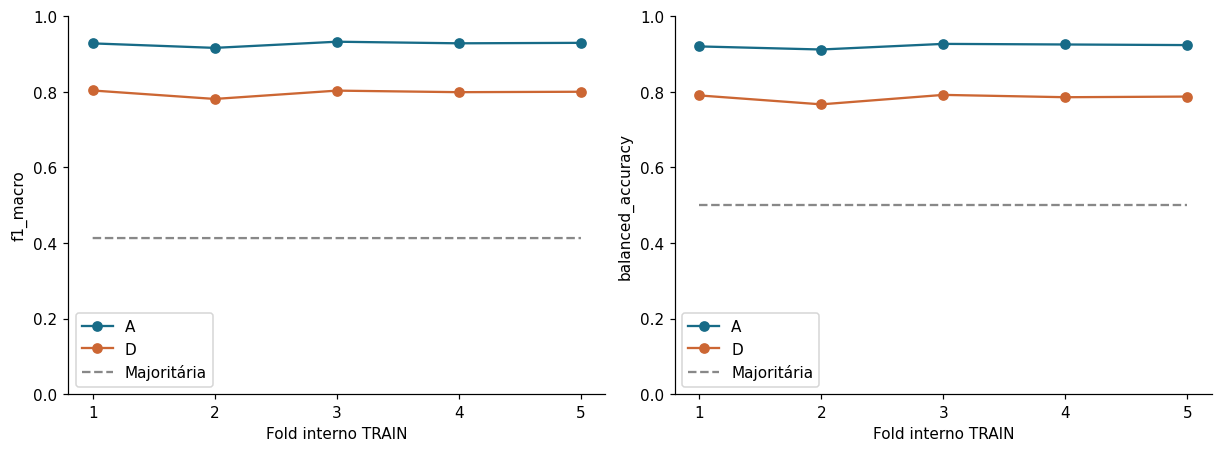

In [4]:
paired = (real_results.query("scenario == 'A'").set_index("fold")[METRICS]
          - real_results.query("scenario == 'D'").set_index("fold")[METRICS])
paired_summary = paired.agg(["mean", "std", "min", "max"])
display(paired.round(6))
display(paired_summary.round(6))
print("Diferenças A - D, mesmos folds; resumo descritivo, sem teste estatístico de independência.")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, metric in zip(axes, ["f1_macro", "balanced_accuracy"], strict=True):
    for scenario, color in [("A", "#176b87"), ("D", "#cc6633")]:
        subset = real_results.query("scenario == @scenario")
        ax.plot(subset["fold"], subset[metric], "o-", label=scenario, color=color)
    ax.plot(real_baseline["fold"], real_baseline[metric], "--", color="#888888", label="Majoritária")
    ax.set(xlabel="Fold interno TRAIN", ylabel=metric, ylim=(0, 1), xticks=range(1, 6))
    ax.legend()
plt.show()


## 3. Controle negativo — uma permutação, somente TRAIN

As labels são embaralhadas entre fornecedores de TRAIN, preservando a quantidade de cada classe. X, IDs e split oficial não mudam. A CV aprende e avalia contra **labels permutadas**, sempre com transformadores internos ao fold. Os folds do controle são estratificados pela label permutada e idênticos para A/D.

Comparar com a baseline majoritária correspondente e ROC-AUC de referência 0,5. Uma accuracy aparentemente alta pode resultar da prevalência. Um resultado baixo é apenas um teste de sanidade: não prova ausência de leakage, validade da label, ausência de proxies ou generalização externa. Uma única permutação não fornece uma distribuição nula para um teste formal.


,regime,scenario,fold,f1_macro,balanced_accuracy,recall_0,recall_1,f1_0,f1_1,roc_auc
0,permuted,A,1,0.413062,0.5,0.0,1.0,0.0,0.826125,0.514036
1,permuted,D,1,0.413062,0.5,0.0,1.0,0.0,0.826125,0.517548
2,permuted,A,2,0.412960,0.5,0.0,1.0,0.0,0.825921,0.502578
3,permuted,D,2,0.412960,0.5,0.0,1.0,0.0,0.825921,0.502043
4,permuted,A,3,0.412960,0.5,0.0,1.0,0.0,0.825921,0.489678
5,permuted,D,3,0.412960,0.5,0.0,1.0,0.0,0.825921,0.494613
6,permuted,A,4,0.412960,0.5,0.0,1.0,0.0,0.825921,0.499027
7,permuted,D,4,0.412960,0.5,0.0,1.0,0.0,0.825921,0.501974
8,permuted,A,5,0.413032,0.5,0.0,1.0,0.0,0.826064,0.495956
9,permuted,D,5,0.413032,0.5,0.0,1.0,0.0,0.826064,0.495931


f1_macro           balanced_accuracy      recall_0      recall_1  \
              mean       std              mean  std     mean  std     mean   
scenario                                                                     
A         0.412995  0.000049               0.5  0.0      0.0  0.0      1.0   
D         0.412995  0.000049               0.5  0.0      0.0  0.0      1.0   

              f1_0          f1_1             roc_auc            
          std mean  std     mean       std      mean       std  
scenario                                                        
A         0.0  0.0  0.0  0.82599  0.000098  0.500255  0.009044  
D         0.0  0.0  0.0  0.82599  0.000098  0.502422  0.009114

,f1_macro,balanced_accuracy,recall_0,recall_1,f1_0,f1_1,roc_auc
mean,0.412995,0.5,0.0,1.0,0.0,0.825990,0.5
std,0.000049,0.0,0.0,0.0,0.0,0.000098,0.0


Uma permutação; seed: 2026 | fingerprint: 16f5cb5d982e5ca8fe7cc82da2be36bda553ee7bdd17371ab2a20f946dc9c657
Labels que mudaram de classe: 7008


,regime,fold,fit_rows,heldout_rows,fit_class0,heldout_class0,heldout_class1,fit_ids_sha256,heldout_ids_sha256
5,permuted,1,13515,3379,4007,1001,2378,858FA0D0108900446EF373BC23EDBEB0456FDC55143C49EC8C37A25C8873364B,2ECA9315C57B116318E7E51943AE565D1D0A376F9D5617C5B0DDD54244398B9F
6,permuted,2,13515,3379,4006,1002,2377,D93A34F369773AF1BC28861486388C16637BFABD93491700ABE5D5720501532B,ADE7C1B77AD30C0A5A3F7DB2EFA5F86453541FE33E4A4B82A57F6F9EF98A9F34
7,permuted,3,13515,3379,4006,1002,2377,0D6F29F9B1B709231BDE88934FDBD3CE018C693A307CFA3516E6C3C1265AC34E,4D6B79766EC736CBE9052D8D64A86E3F5154D53602BBB26BAD814ED9693773B1
8,permuted,4,13515,3379,4006,1002,2377,5537E8CF4500A0F42C27152356368087E443E53D7EAEE453AE95D2DC8BC54BE9,C8F1DBB2B8E59CF9AC72135C4889EF7BC9562425D26DEE109B1A483A953464CA
9,permuted,5,13516,3378,4007,1001,2377,5B28FBB6345CCAF90F681556B673AD21F77BA71D841C5242E0EA21EA9D702A89,38DFD608F7CB98FF605D582BA0BE2E2CC4FA271BFEB301B7DF5B1BBE9164C1B3


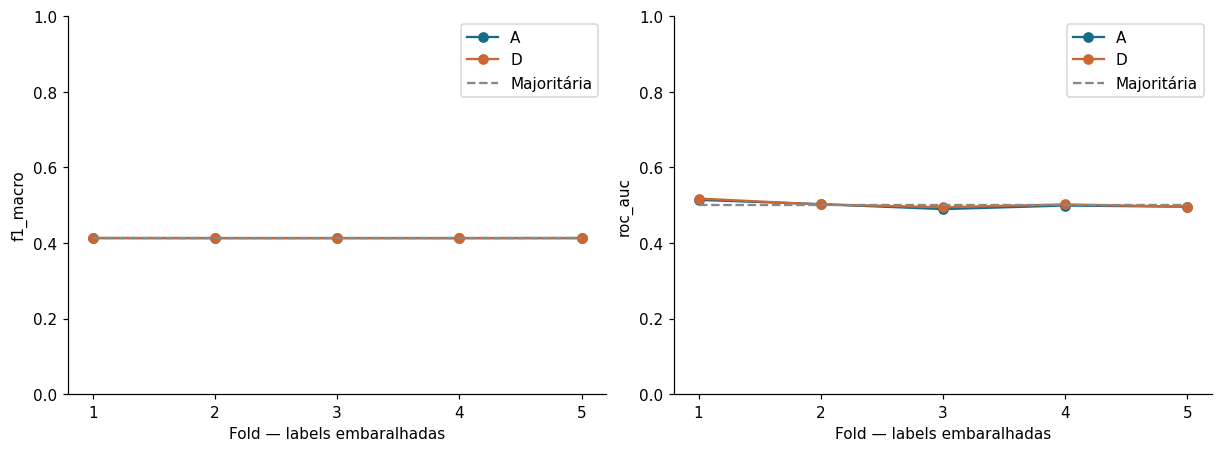

In [5]:
y_permuted = pd.Series(
    np.random.default_rng(PERMUTATION_SEED).permutation(y.to_numpy()),
    index=y.index, name="risk_level",
)
np.testing.assert_array_equal(np.sort(y_permuted), np.sort(y))
assert not np.array_equal(y_permuted, y)
PERMUTED_HASH = hashlib.sha256(y_permuted.to_numpy().tobytes()).hexdigest()
NEGATIVE_FOLDS = create_folds(y_permuted)
negative_results, negative_baseline = run_cv(y_permuted, NEGATIVE_FOLDS, "permuted")
negative_summary = negative_results.groupby("scenario")[METRICS].agg(["mean", "std"])
display(negative_results.round(6))
display(negative_summary.round(6))
display(negative_baseline[METRICS].agg(["mean", "std"]).round(6))
print("Uma permutação; seed:", PERMUTATION_SEED, "| fingerprint:", PERMUTED_HASH)
print("Labels que mudaram de classe:", int(y.ne(y_permuted).sum()))
display(pd.DataFrame(fold_records).query("regime == 'permuted'"))
assert frame_hash(train) == TRAIN_FRAME_HASH
np.testing.assert_array_equal(y, train["risk_level"])
assert len(FIT_AUDIT) == 20
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, metric in zip(axes, ["f1_macro", "roc_auc"], strict=True):
    for scenario, color in [("A", "#176b87"), ("D", "#cc6633")]:
        part = negative_results.query("scenario == @scenario")
        ax.plot(part["fold"], part[metric], "o-", label=scenario, color=color)
    ax.plot(negative_baseline["fold"], negative_baseline[metric], "--", color="#888888", label="Majoritária")
    ax.set(xlabel="Fold — labels embaralhadas", ylabel=metric, ylim=(0, 1), xticks=range(1, 6))
    ax.legend()
plt.show()


## 4. Reprodução diagnóstica dos erros da LR A

Somente agora selecionamos VALIDATION por ID. O fit de diagnóstico usa todo o TRAIN original, sem ajuste de configuração ou threshold. As medianas devem coincidir com o produtor ML-Ready; coeficientes e matriz devem reproduzir o notebook 02. Se não coincidirem, a análise é interrompida em vez de substituir silenciosamente o experimento anterior.

FP = classe real 0 prevista como 1; FN = classe real 1 prevista como 0. Para investigar missing, compliance > 100 e lead time zero, usar as features **pré-imputação** de VALIDATION associadas aos mesmos IDs. Flags servem somente ao diagnóstico; não são features.

Taxas condicionais: FP / total de classe 0 no grupo; FN / total de classe 1 no grupo. Exibir denominadores e referências sem a condição. Isso evita confundir predominância de um grupo entre erros com maior taxa de erro. Grupos se sobrepõem; valores ausentes de compliance/lead time são categoria separada, não o grupo de referência.


In [6]:
validation = load_partition("validation")
VALIDATION_FRAME_HASH = frame_hash(validation)
assert len(validation) == 3539
assert not set(train["supplier_id"]) & set(validation["supplier_id"])
X_validation = validation[FEATURES].copy()
y_validation = validation["risk_level"].copy()
baseline_replay = checked_fit(X, y, "diagnostic_replay_LR_A")
np.testing.assert_allclose(
    baseline_replay.named_steps["imputer"].statistics_,
    [CONTRACT["medians"][f] for f in FEATURES], rtol=1e-12,
)
np.testing.assert_array_equal(
    baseline_replay.named_steps["imputer"].transform(X),
    X.fillna(CONTRACT["medians"]).to_numpy(),
)
prediction, probability = checked_predict(baseline_replay, X_validation)
observed_cm = confusion_matrix(y_validation, prediction, labels=[0, 1])
expected_cm = np.array([[979, 131], [81, 2348]])
np.testing.assert_array_equal(observed_cm, expected_cm)
replay_metrics = evaluate(y_validation, prediction, probability)
EXPECTED_METRICS = {
    "f1_macro": 0.92955, "balanced_accuracy": 0.92432,
    "recall_0": 0.88198, "recall_1": 0.96665, "f1_0": 0.90230, "f1_1": 0.95681,
    "roc_auc": 0.98765,
}
for metric, expected in EXPECTED_METRICS.items():
    assert abs(replay_metrics[metric] - expected) <= 0.000006, (metric, replay_metrics[metric])
EXPECTED_COEFFICIENTS = [-5.62404, -0.77630, 0.10179, 4.20136, 0.50473,
                         -2.43159, 1.46598, -1.82045, 1.90549, 0.03133]
replay_coef = baseline_replay.named_steps["model"].coef_[0]
np.testing.assert_allclose(replay_coef, EXPECTED_COEFFICIENTS, atol=0.000006, rtol=0)
assert abs(baseline_replay.named_steps["model"].intercept_[0] - 3.526334292073002) < 1e-9
diagnosis = validation[["supplier_id", "risk_level", *FEATURES]].copy()
diagnosis["prediction"] = prediction
diagnosis["p_class1_uncalibrated"] = probability
diagnosis["outcome"] = np.select(
    [y_validation.eq(0) & (prediction == 0), y_validation.eq(0) & (prediction == 1),
     y_validation.eq(1) & (prediction == 0)],
    ["TN", "FP", "FN"], default="TP",
)
print("Reprodução compatível com métricas, coeficientes e matriz publicados no notebook 02:")
display(pd.DataFrame(observed_cm, index=["real_0", "real_1"], columns=["prev_0", "prev_1"]))
display(pd.Series(replay_metrics, name="LR_A_validation").round(6))
print("Nulos originais de VALIDATION:", int(X_validation.isna().sum().sum()))
print("Fingerprint das predições reconstruídas:", hashlib.sha256(prediction.tobytes()).hexdigest())
print("Não existe vetor antigo persistido para comparação bit a bit.")
assert len(FIT_AUDIT) == 21


Reprodução compatível com métricas, coeficientes e matriz publicados no notebook 02:


,prev_0,prev_1
real_0,979,131
real_1,81,2348


f1_macro             0.929555
balanced_accuracy    0.924317
recall_0             0.881982
recall_1             0.966653
f1_0                 0.902304
f1_1                 0.956805
roc_auc              0.987653
Name: LR_A_validation, dtype: float64

Nulos originais de VALIDATION: 231
Fingerprint das predições reconstruídas: 2e78d66a35ed04a43991161e81feb81b161e6e88b491c6ee6b33245b201048a5
Não existe vetor antigo persistido para comparação bit a bit.


,condition,group,n,class0,FP,FPR,class1,FN,FNR
0,any_missing,present,225,75,9,0.120000,150,14,0.093333
1,any_missing,reference,3314,1035,122,0.117874,2279,67,0.029399
2,environmental_compliance_gt100,present,185,79,7,0.088608,106,4,0.037736
3,environmental_compliance_gt100,reference,3308,1017,123,0.120944,2291,75,0.032737
4,environmental_compliance_gt100,unknown,46,14,1,0.071429,32,2,0.062500
5,lead_time_days_eq0,present,181,57,5,0.087719,124,5,0.040323
6,lead_time_days_eq0,reference,3332,1045,126,0.120574,2287,75,0.032794
7,lead_time_days_eq0,unknown,26,8,0,0.000000,18,1,0.055556


,condition,group,n,class0,FP,FPR,class1,FN,FNR
0,financial_stability_score,missing,54,16,4,0.250000,38,4,0.105263
1,financial_stability_score,observed,3485,1094,127,0.116088,2391,77,0.032204
2,on_time_delivery_rate,missing,23,6,0,0.000000,17,0,0.000000
3,on_time_delivery_rate,observed,3516,1104,131,0.118659,2412,81,0.033582
4,defect_rate,missing,44,21,4,0.190476,23,2,0.086957
5,defect_rate,observed,3495,1089,127,0.116621,2406,79,0.032835
6,geopolitical_risk_index,observed,3539,1110,131,0.118018,2429,81,0.033347
7,lead_time_days,missing,26,8,0,0.000000,18,1,0.055556
8,lead_time_days,observed,3513,1102,131,0.118875,2411,80,0.033181
9,alternative_suppliers_available,missing,20,6,0,0.000000,14,4,0.285714


,count,mean,max
outcome,,,
TP,2348,0.060477,2
TN,979,0.067416,1
FN,81,0.172840,1
FP,131,0.068702,1


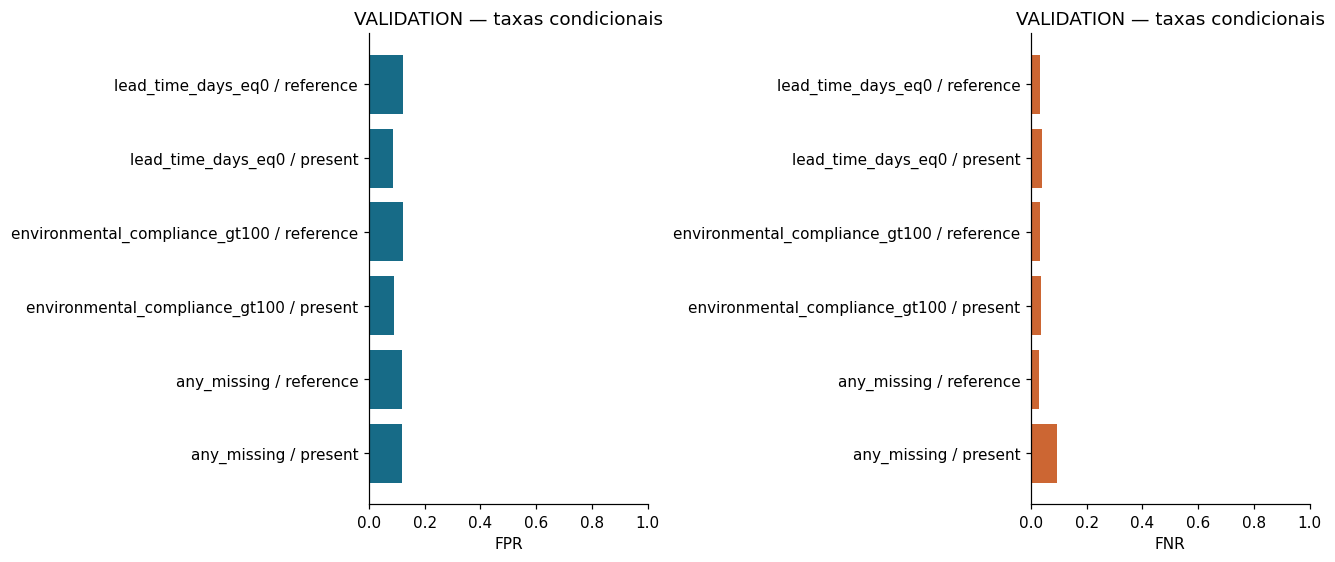

present = condição presente; reference = condição ausente e valor conhecido.
unknown = feature nula; grupos podem se sobrepor; não há teste causal ou ajuste automático.


In [7]:
def subgroup_rates(name, state):
    rows = []
    for group in sorted(state.unique()):
        mask = state.eq(group)
        part = diagnosis.loc[mask]
        n0, n1 = int(part["risk_level"].eq(0).sum()), int(part["risk_level"].eq(1).sum())
        fp, fn = int(part["outcome"].eq("FP").sum()), int(part["outcome"].eq("FN").sum())
        rows.append({
            "condition": name, "group": group, "n": len(part),
            "class0": n0, "FP": fp, "FPR": fp / n0 if n0 else np.nan,
            "class1": n1, "FN": fn, "FNR": fn / n1 if n1 else np.nan,
        })
    return rows

any_missing = X_validation.isna().any(axis=1)
quality_states = {
    "any_missing": pd.Series(np.where(any_missing, "present", "reference"), index=diagnosis.index),
    "environmental_compliance_gt100": pd.Series(np.select(
        [X_validation["environmental_compliance"].isna(),
         X_validation["environmental_compliance"].gt(100)],
        ["unknown", "present"], default="reference",
    ), index=diagnosis.index),
    "lead_time_days_eq0": pd.Series(np.select(
        [X_validation["lead_time_days"].isna(), X_validation["lead_time_days"].eq(0)],
        ["unknown", "present"], default="reference",
    ), index=diagnosis.index),
}
quality_rows = []
for name, states in quality_states.items():
    quality_rows.extend(subgroup_rates(name, states))
quality_rates = pd.DataFrame(quality_rows)
display(quality_rates.round(6))
missing_rows = []
for feature in FEATURES:
    states = pd.Series(np.where(X_validation[feature].isna(), "missing", "observed"), index=diagnosis.index)
    missing_rows.extend(subgroup_rates(feature, states))
missing_rates = pd.DataFrame(missing_rows)
display(missing_rates.round(6))
coverage_by_outcome = (diagnosis.assign(missing_count=X_validation.isna().sum(axis=1))
                       .groupby("outcome", sort=False)["missing_count"].agg(["count", "mean", "max"]))
display(coverage_by_outcome.round(6))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
plot_data = quality_rates.loc[quality_rates["group"].ne("unknown")].copy()
plot_labels = plot_data["condition"] + " / " + plot_data["group"]
for ax, metric, color in zip(axes, ["FPR", "FNR"], ["#176b87", "#cc6633"], strict=True):
    ax.barh(plot_labels, plot_data[metric], color=color)
    ax.set(xlabel=metric, xlim=(0, 1), title="VALIDATION — taxas condicionais")
plt.show()
print("present = condição presente; reference = condição ausente e valor conhecido.")
print("unknown = feature nula; grupos podem se sobrepor; não há teste causal ou ajuste automático.")


,outcome,feature,n,present,missing,mean,median,q25,q75
0,TN,financial_stability_score,979,967,12,69.27481,69.74777,60.77581,76.77990
1,TN,on_time_delivery_rate,979,973,6,78.46634,78.28663,70.92686,87.09762
2,TN,defect_rate,979,962,17,4.63631,4.25286,2.13367,6.94595
3,TN,geopolitical_risk_index,979,979,0,22.72829,13.00000,12.00000,31.00000
4,TN,lead_time_days,979,971,8,25.13697,25.00000,15.00000,34.00000
5,TN,alternative_suppliers_available,979,973,6,3.57451,4.00000,2.00000,5.00000
6,TN,contract_length_months,979,979,0,16.92033,17.00000,8.00000,24.00000
7,TN,environmental_compliance,979,966,13,75.20829,76.35000,64.52250,86.91000
8,TN,previous_disruptions,979,975,4,0.70769,1.00000,0.00000,1.00000
9,TN,supplier_record_count,979,979,0,1.01736,1.00000,1.00000,1.00000


,count,mean,median,min,max
outcome,,,,,
FN,81,0.347425,0.370262,0.038549,0.493193
FP,131,0.736066,0.750831,0.502609,0.995026
TN,979,0.058874,0.004119,0.000000,0.488972
TP,2348,0.961491,0.998534,0.502176,1.000000


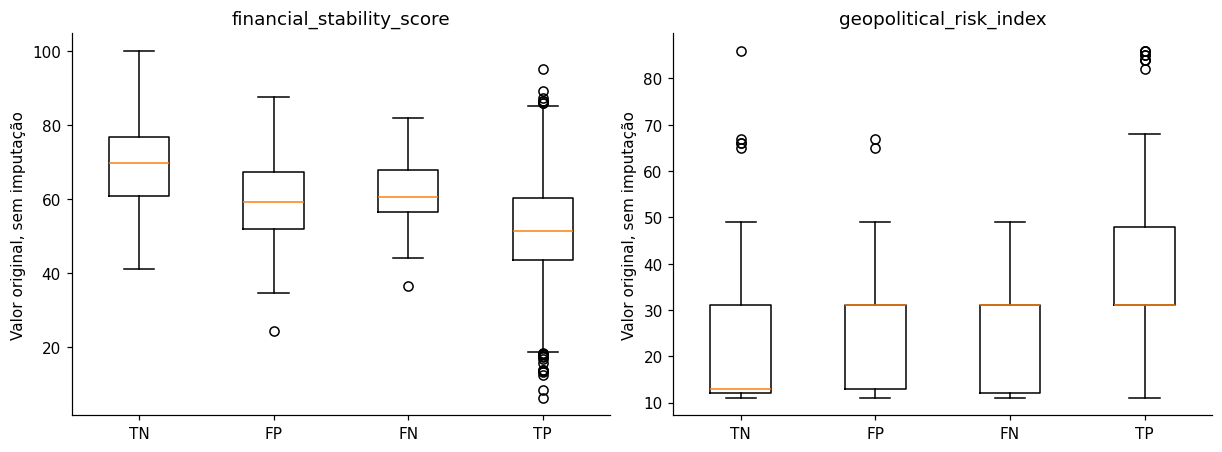

Comparações relevantes: FP versus TN (classe real 0); FN versus TP (classe real 1).
Probabilidades são estimativas não calibradas de pertencimento à classe 1; não probabilidade de falha.


In [8]:
# Medianas/quantis ignoram nulos; o suporte por feature é exibido explicitamente.
feature_error_rows = []
for outcome in ["TN", "FP", "FN", "TP"]:
    part = diagnosis.loc[diagnosis["outcome"].eq(outcome), FEATURES]
    for feature in FEATURES:
        values = part[feature]
        feature_error_rows.append({
            "outcome": outcome, "feature": feature, "n": len(values),
            "present": int(values.notna().sum()), "missing": int(values.isna().sum()),
            "mean": float(values.mean()), "median": float(values.median()),
            "q25": float(values.quantile(.25)), "q75": float(values.quantile(.75)),
        })
feature_errors = pd.DataFrame(feature_error_rows)
display(feature_errors.round(5))
probability_groups = diagnosis.groupby("outcome")["p_class1_uncalibrated"].agg(
    ["count", "mean", "median", "min", "max"],
)
display(probability_groups.round(6))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, feature in zip(axes, ["financial_stability_score", "geopolitical_risk_index"], strict=True):
    groups = [diagnosis.loc[diagnosis["outcome"].eq(o), feature].dropna() for o in ["TN", "FP", "FN", "TP"]]
    ax.boxplot(groups, tick_labels=["TN", "FP", "FN", "TP"], showfliers=True)
    ax.set(title=feature, ylabel="Valor original, sem imputação")
plt.show()
print("Comparações relevantes: FP versus TN (classe real 0); FN versus TP (classe real 1).")
print("Probabilidades são estimativas não calibradas de pertencimento à classe 1; não probabilidade de falha.")


## 5. Coeficientes: observação versus hipótese

Coeficientes referem-se à LR regularizada, em unidades padronizadas com estatísticas de cada subtreino. Sinal positivo aumenta o log-odds estimado da classe 1, condicionando nas demais features. Comparações de magnitude entre folds/A/D são descritivas: as escalas aprendidas e a especificação mudam.

**OBSERVAÇÃO:** registrar magnitude, dispersão e sinais dos coeficientes, sobretudo estabilidade financeira e índice geopolítico. A remoção conjunta em D não separa o efeito das duas features; para isso, consultar as ablações B/C anteriores, sem executá-las novamente.

**HIPÓTESE:** sinais estáveis e forte dependência podem ser compatíveis com participação das features na regra de construção da label ou com outras relações da fonte. Isso não comprova causalidade, fórmula original ou validade empresarial.

geopolitical_risk_index permanece provisório: origem, fórmula e referência temporal não comprovadas. supplier_record_count conta registros distintos após deduplicação, não histórico temporal; pode refletir coleta/completude. Nenhuma variável é removida automaticamente.


mean       std       min  \
scenario feature                                                         
A        alternative_suppliers_available -2.414542  0.037943 -2.463984   
         contract_length_months           1.455046  0.027702  1.421782   
         defect_rate                      0.101671  0.021044  0.066912   
         environmental_compliance        -1.807345  0.018845 -1.829696   
         financial_stability_score       -5.584237  0.056513 -5.652106   
         geopolitical_risk_index          4.171352  0.057630  4.078827   
         lead_time_days                   0.501444  0.015290  0.487249   
         on_time_delivery_rate           -0.770297  0.020498 -0.795435   
         previous_disruptions             1.891486  0.018348  1.866940   
         supplier_record_count            0.030233  0.012038  0.019319   
D        alternative_suppliers_available -0.904143  0.010922 -0.916471   
         contract_length_months           0.584013  0.018859  0.569482   
         defect_rate                      0.054858  0.015936  0.027938   
         environmental_compliance        -0.671430  0.016524 -0.693215   
         financial_stability_score       -2.124100  0.013284 -2.142610   
         lead_time_days                   0.195153  0.007475  0.185962   
         on_time_delivery_rate           -0.300695  0.009676 -0.313554   
         previous_disruptions             0.738752  0.016624  0.724277   

                                               max  positive_folds  \
scenario feature                                                     
A        alternative_suppliers_available -2.375284               0   
         contract_length_months           1.495015               5   
         defect_rate                      0.118422               5   
         environmental_compliance        -1.787460               0   
         financial_stability_score       -5.509226               0   
         geopolitical_risk_index          4.222105               5   
         lead_time_days                   0.522915               5   
         on_time_delivery_rate           -0.746638               0   
         previous_disruptions             1.914826               5   
         supplier_record_count            0.047888               5   
D        alternative_suppliers_available -0.890797               0   
         contract_length_months           0.614447               5   
         defect_rate                      0.070156               5   
         environmental_compliance        -0.651537               0   
         financial_stability_score       -2.110440               0   
         lead_time_days                   0.204077               5   
         on_time_delivery_rate           -0.288467               0   
         previous_disruptions             0.760258               5   

                                          negative_folds  
scenario feature                                          
A        alternative_suppliers_available               5  
         contract_length_months                        0  
         defect_rate                                   0  
         environmental_compliance                      5  
         financial_stability_score                     5  
         geopolitical_risk_index                       0  
         lead_time_days                                0  
         on_time_delivery_rate                         5  
         previous_disruptions                          0  
         supplier_record_count                         0  
D        alternative_suppliers_available               5  
         contract_length_months                        0  
         defect_rate                                   0  
         environmental_compliance                      5  
         financial_stability_score                     5  
         lead_time_days                                0  
         on_time_delivery_rate                         5  
         previous_disruptions              

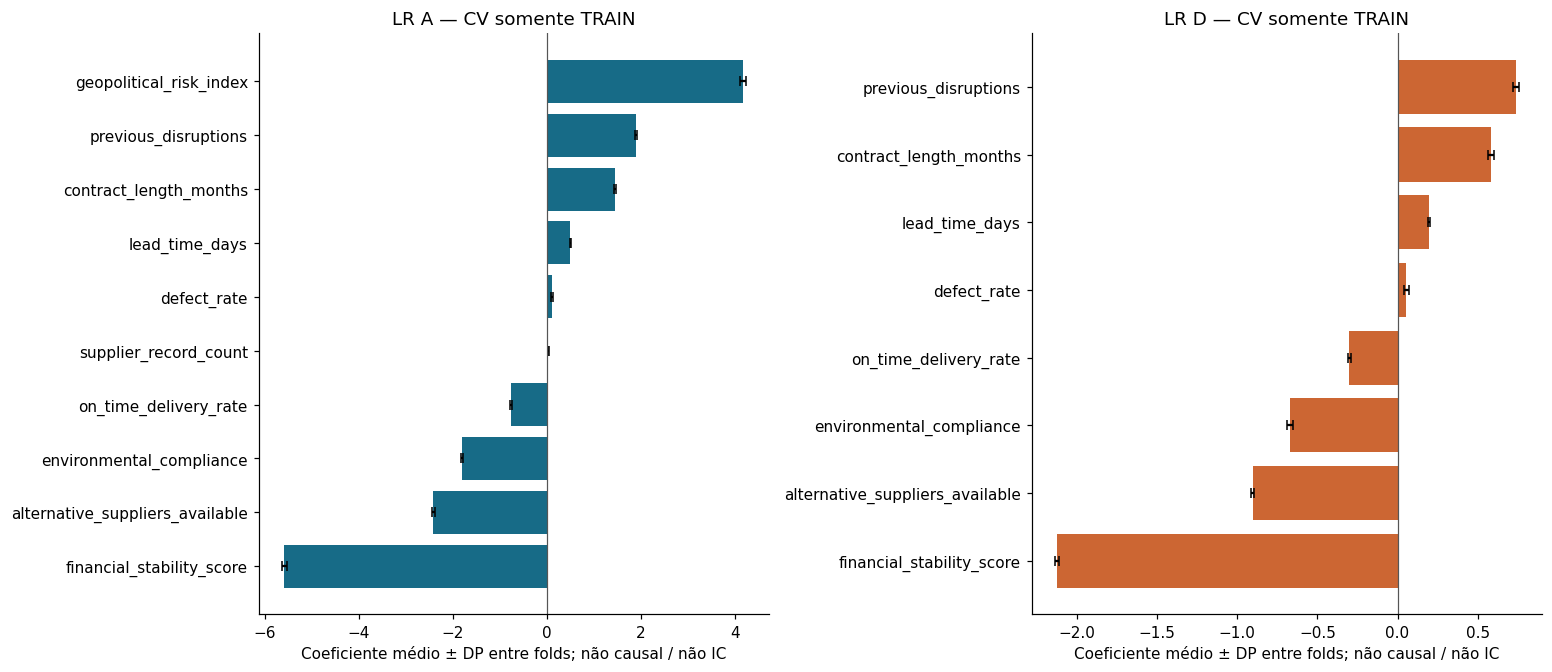

In [9]:
coefficients = pd.DataFrame(coefficient_records)
coefficient_summary = coefficients.groupby(["scenario", "feature"])["coefficient_standardized"].agg(
    ["mean", "std", "min", "max"],
)
coefficient_summary["positive_folds"] = coefficients.assign(
    positive=coefficients["coefficient_standardized"].gt(0),
).groupby(["scenario", "feature"])["positive"].sum()
coefficient_summary["negative_folds"] = coefficients.assign(
    negative=coefficients["coefficient_standardized"].lt(0),
).groupby(["scenario", "feature"])["negative"].sum()
display(coefficient_summary.round(6))
fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
for ax, scenario, color in zip(axes, ["A", "D"], ["#176b87", "#cc6633"], strict=True):
    part = coefficient_summary.loc[scenario].sort_values("mean")
    ax.barh(part.index, part["mean"], xerr=part["std"], color=color, capsize=3)
    ax.axvline(0, color="#555555", linewidth=.8)
    ax.set(title=f"LR {scenario} — CV somente TRAIN", xlabel="Coeficiente médio ± DP entre folds; não causal / não IC")
plt.show()


## 6. Conclusões científicas exploratórias

### Resultados observados nesta execução

- **CV real:** A teve F1-macro 0,92683 ± 0,00624 e balanced accuracy 0,92141 ± 0,00592; D teve 0,79729 ± 0,00929 e 0,78435 ± 0,01014. A foi superior nos cinco folds; delta médio F1 A − D = +0,12954. São médias/DP descritivos, não intervalos de confiança.
- **Controle negativo:** A/D ficaram em F1-macro 0,41300 e balanced accuracy 0,50000, prevendo somente classe 1. ROC-AUC médio: 0,50025/0,50242. O comportamento coincide com a referência trivial nesse controle; não prova ausência absoluta de leakage.
- **Erros reconstruídos:** matriz anterior reproduzida (TN 979, FP 131, FN 81, TP 2348). Com alguma feature nula, FNR = 14/150 = 9,33%; sem nulos, 67/2279 = 2,94%. Compliance > 100 e lead time zero não tiveram piora uniforme de FP/FN; os grupos são sobrepostos e os suportes limitados.
- **Coeficientes A:** estabilidade financeira −5,58424 ± 0,05651; índice geopolítico +4,17135 ± 0,05763, com sinais constantes nos cinco folds. Contagem +0,03023 ± 0,01204; A/D não separa sua contribuição da do índice.

### Hipóteses e limites de interpretação

O sinal se mantém nesta CV interna e desaparece com labels embaralhadas. Isso fortalece a evidência classificatória dentro da fonte, não comprova validade empresarial ou independência da regra de construção de Risk_Level. A diferença A/D é compatível com dependência das variáveis excluídas; a procedência do índice continua desconhecida. Ausência de valores pode se associar à dificuldade da classe 1, mas os dados não demonstram que seja a causa dos erros. Nenhuma correção automática foi aplicada.

Relatório completo: [supplier_risk_validation_analysis.md](../../../docs/supplier_risk_validation_analysis.md).

Os resultados abaixo são resumos descritivos, não aprovação de um modelo definitivo. A dispersão entre folds não representa toda a incerteza: há somente uma fonte, um particionamento interno e uma permutação negativa. VALIDATION já foi consultada na rodada anterior e agora para diagnóstico; não é um novo holdout independente.

A investigação de erros é pós-hoc, com grupos sobrepostos e suportes desiguais. Não confundir associação com missing/compliance/lead time com causa dos erros. Campos com poucos casos devem ser tratados como inconclusivos. A/D avalia remoção conjunta; não permite atribuir toda a diferença à contagem ou ao índice isoladamente.

A explicação de Risk_Level continua pendente. Nenhuma estabilidade estatística demonstrada aqui comprova previsão temporal, falha, fraude ou risco empresarial. Probabilidades não foram calibradas. TEST continua reservado para uma avaliação final futura, após decisão explícita de configuração, não autorizada por este notebook.


In [10]:
print("CV real: média ± DP de F1-macro e balanced accuracy")
for scenario in FEATURE_SETS:
    subset = real_results.query("scenario == @scenario")
    print(scenario, {m: (float(subset[m].mean()), float(subset[m].std())) for m in METRICS})
print("A - D, deltas por fold e média, apenas descrição:")
display(paired[["f1_macro", "balanced_accuracy"]].round(6))
print("Controle negativo: referência majoritária e modelos — média")
display(pd.concat([
    negative_results.groupby("scenario")[METRICS].mean(),
    negative_baseline[METRICS].mean().to_frame("majoritária").T,
]).round(6))
print("Taxas de erro da LR A reproduzida; confirmar denominadores antes de interpretar:")
display(quality_rates.round(6))
print("Impacto do índice não comprova sua origem; contagem não comprova histórico.")
print("Sem teste de significância entre folds, tuning, threshold escolhido ou abertura de TEST.")


CV real: média ± DP de F1-macro e balanced accuracy
A {'f1_macro': (0.9268299998551799, 0.0062401889904633405), 'balanced_accuracy': (0.9214135496966371, 0.005915629486458085), 'recall_0': (0.8763964578335836, 0.009475038050240492), 'recall_1': (0.9664306415596904, 0.005610931446857596), 'f1_0': (0.8960943035293711, 0.00875976853688867), 'f1_1': (0.9575656961809887, 0.003740244399631363), 'roc_auc': (0.9846202002199428, 0.0017802341059896013)}
D {'f1_macro': (0.7972880029406296, 0.0092857494208623), 'balanced_accuracy': (0.7843453522814926, 0.010142062411312765), 'recall_0': (0.6499630110408553, 0.01957551253086371), 'recall_1': (0.9187276935221298, 0.0023777837419190558), 'f1_0': (0.7052788190787288, 0.014554669965367662), 'f1_1': (0.8892971868025302, 0.004060914050749278), 'roc_auc': (0.8999058930200317, 0.003402557759515249)}
A - D, deltas por fold e média, apenas descrição:


,f1_macro,balanced_accuracy
fold,,
1,0.124618,0.129627
2,0.135096,0.145076
3,0.129378,0.134919
4,0.129248,0.139509
5,0.129370,0.136210


Controle negativo: referência majoritária e modelos — média


,f1_macro,balanced_accuracy,recall_0,recall_1,f1_0,f1_1,roc_auc
A,0.412995,0.5,0.0,1.0,0.0,0.82599,0.500255
D,0.412995,0.5,0.0,1.0,0.0,0.82599,0.502422
majoritária,0.412995,0.5,0.0,1.0,0.0,0.82599,0.500000


Taxas de erro da LR A reproduzida; confirmar denominadores antes de interpretar:


,condition,group,n,class0,FP,FPR,class1,FN,FNR
0,any_missing,present,225,75,9,0.120000,150,14,0.093333
1,any_missing,reference,3314,1035,122,0.117874,2279,67,0.029399
2,environmental_compliance_gt100,present,185,79,7,0.088608,106,4,0.037736
3,environmental_compliance_gt100,reference,3308,1017,123,0.120944,2291,75,0.032737
4,environmental_compliance_gt100,unknown,46,14,1,0.071429,32,2,0.062500
5,lead_time_days_eq0,present,181,57,5,0.087719,124,5,0.040323
6,lead_time_days_eq0,reference,3332,1045,126,0.120574,2287,75,0.032794
7,lead_time_days_eq0,unknown,26,8,0,0.000000,18,1,0.055556


Impacto do índice não comprova sua origem; contagem não comprova histórico.
Sem teste de significância entre folds, tuning, threshold escolhido ou abertura de TEST.


## 7. Integridade, rastreabilidade e dados para o relatório

As tabelas agregadas abaixo são incorporadas ao notebook, não exportadas como dataset ou modelo. Não são exibidos IDs individuais de fornecedores. Modelos ficam apenas em memória. As validações são executadas com assert; não rodar o notebook com Python otimizado (-O).

Versões e hashes da entrada foram registrados; a matriz anterior, os coeficientes publicados e os erros agregados foram conferidos. A comparação com o vetor de predições antigo permanece impossível porque ele não foi persistido.


In [11]:
assert len(FIT_AUDIT) == 21
assert all(r["fit_warnings"] == 0 for r in FIT_AUDIT)
assert len(real_results) == len(negative_results) == 10
assert len(coefficient_records) == 90
assert READ_LOG == [
    "split:train", "features:train", "targets:train",
    "split:validation", "features:validation", "targets:validation",
]
assert X.equals(train[FEATURES]) and y.equals(train["risk_level"])
assert frame_hash(train) == TRAIN_FRAME_HASH
assert frame_hash(validation) == VALIDATION_FRAME_HASH
assert {name: sha256(path) for name, path in INPUTS.items()} == INPUT_HASHES
assert sha256(METADATA_PATH) == METADATA_HASH and sha256(PRIOR_NOTEBOOK) == PRIOR_HASH
assert not real_results[METRICS].isna().any().any()
assert not negative_results[METRICS].isna().any().any()
display(pd.DataFrame(FIT_AUDIT))
print("21 ajustes experimentais; zero avisos de fit; zero modelos serializados.")
print("Fontes, base, targets, split, metadata e notebook anterior preservados.")
print("Nenhum Parquet TEST ou X_train ML-Ready carregado; sem seleção de linhas TEST.")

def records(frame):
    return json.loads(frame.to_json(orient="records", double_precision=12))

def summarize(frame):
    return [
        {"scenario": scenario,
         **{f"{metric}_{stat}": float(getattr(part[metric], stat)())
            for metric in METRICS for stat in ("mean", "std")}}
        for scenario, part in frame.groupby("scenario")
    ]

REPORT = {
    "protocol_version": "1.0",
    "cv_seed": CV_SEED, "permutation_seed": PERMUTATION_SEED,
    "train_rows": len(train), "validation_rows": len(validation),
    "real_summary": summarize(real_results),
    "negative_summary": summarize(negative_results),
    "real_folds": records(real_results), "negative_folds": records(negative_results),
    "real_baseline": records(real_baseline), "negative_baseline": records(negative_baseline),
    "paired_deltas": records(paired.reset_index()),
    "quality_rates": records(quality_rates), "missing_rates": records(missing_rates),
    "feature_errors": records(feature_errors),
    "coefficient_summary": records(coefficient_summary.reset_index()),
    "replay_metrics": replay_metrics, "replay_cm": observed_cm.tolist(),
    "read_log": READ_LOG, "fits": len(FIT_AUDIT),
}
print("VALIDATION_REPORT_JSON=" + json.dumps(REPORT, ensure_ascii=False, allow_nan=False))


,context,fit_rows,n_features,imputer_subtrain_verified,scaler_subtrain_verified,fit_warnings
0,real_A_fold1,13515,10,True,True,0
1,real_D_fold1,13515,8,True,True,0
2,real_A_fold2,13515,10,True,True,0
3,real_D_fold2,13515,8,True,True,0
4,real_A_fold3,13515,10,True,True,0
5,real_D_fold3,13515,8,True,True,0
6,real_A_fold4,13515,10,True,True,0
7,real_D_fold4,13515,8,True,True,0
8,real_A_fold5,13516,10,True,True,0
9,real_D_fold5,13516,8,True,True,0


21 ajustes experimentais; zero avisos de fit; zero modelos serializados.
Fontes, base, targets, split, metadata e notebook anterior preservados.
Nenhum Parquet TEST ou X_train ML-Ready carregado; sem seleção de linhas TEST.
VALIDATION_REPORT_JSON={"protocol_version": "1.0", "cv_seed": 42, "permutation_seed": 2026, "train_rows": 16894, "validation_rows": 3539, "real_summary": [{"scenario": "A", "f1_macro_mean": 0.9268299998551799, "f1_macro_std": 0.0062401889904633405, "balanced_accuracy_mean": 0.9214135496966371, "balanced_accuracy_std": 0.005915629486458085, "recall_0_mean": 0.8763964578335836, "recall_0_std": 0.009475038050240492, "recall_1_mean": 0.9664306415596904, "recall_1_std": 0.005610931446857596, "f1_0_mean": 0.8960943035293711, "f1_0_std": 0.00875976853688867, "f1_1_mean": 0.9575656961809887, "f1_1_std": 0.003740244399631363, "roc_auc_mean": 0.9846202002199428, "roc_auc_std": 0.0017802341059896013}, {"scenario": "D", "f1_macro_mean": 0.7972880029406296, "f1_macro_std": 0.009